In [4]:
import uproot
import numpy as np
import skhep_testdata, uproot
import awkward as ak
import particle
from hepunits import GeV
import vector
import matplotlib.pyplot as plt

# Foundational Code

In [5]:
file_names = ["nano_100_0p25_0p02.root", "nano_800_0p25_0p0025.root", "nano_1000_0p25_0p002.root", "nano_1000_0p25_2p0.root", "nano_1000_5p0_0p04.root"]


branches_dict = {}

for file_name in file_names:

    with uproot.open(file_name) as temp_file:
        tree = temp_file['Events']
        branches = tree.arrays(filter_name=["Muon_*", "Electron_*", "GenPart_*"])
        
    #Build Vectors
    muon = vector.zip({"pt": branches['Muon_pt'], "eta": branches['Muon_eta'], "phi": branches['Muon_phi'], "mass": branches['Muon_mass'], "looseId": branches['Muon_looseId']})
    electron_p4 = vector.zip({"pt": branches['Electron_pt'], "eta": branches['Electron_eta'], "phi": branches['Electron_phi'], "mass": branches['Electron_mass']})
    gen = vector.zip({"pt": branches['GenPart_pt'], "eta": branches['GenPart_eta'], "phi": branches['GenPart_phi'], "mass": branches['GenPart_mass'], "id": branches['GenPart_pdgId'], "status": branches['GenPart_status']}) 
    
    #Apply masks
    is_electron = (abs(gen.id) == 11) & (gen.status == 1)
    is_muon = (abs(gen.id) == 13) & (gen.status == 1)
    #Hypothetical particles used for comparison in reconstruction
    is_dark_photon = (gen.id == 32) #& (gen.status == 22)
    is_bound_state = (gen.id == 35) & (gen.status == 22)
    
    gen_electrons = gen[is_electron]
    gen_muons = gen[is_muon]
    gen_dark_photon = gen[is_dark_photon]
    
    correct_electron_pair = ak.sum(gen_electrons.id, axis=1) == 0
    correct_muon_pair = ak.sum(gen_muons.id, axis=1) == 0

    event_mask = (ak.num(gen_electrons) == 2) & (ak.num(gen_muons) == 2) & correct_electron_pair & correct_muon_pair

    leading_e = gen_electrons[event_mask][:,0]
    subleading_e = gen_electrons[event_mask][:,1]
    
    leading_mu = gen_muons[event_mask][:,0]
    subleading_mu = gen_muons[event_mask][:,1]

    e_pair = leading_e + subleading_e
    mu_pair = leading_mu + subleading_mu
    bound_state = e_pair + mu_pair
    

    # Save the processed data into the dictionary under the file's name
    branches_dict[file_name] = {
        "e_pair": e_pair,
        "mu_pair": mu_pair,
        "bound_state": bound_state,
        "dark_photon": ak.flatten(gen_dark_photon),
        "leading_e": leading_e,        
        "subleading_e": subleading_e,
        "leading_mu": leading_mu,    
        "subleading_mu": subleading_mu  
    }

# Reconstructed Masses


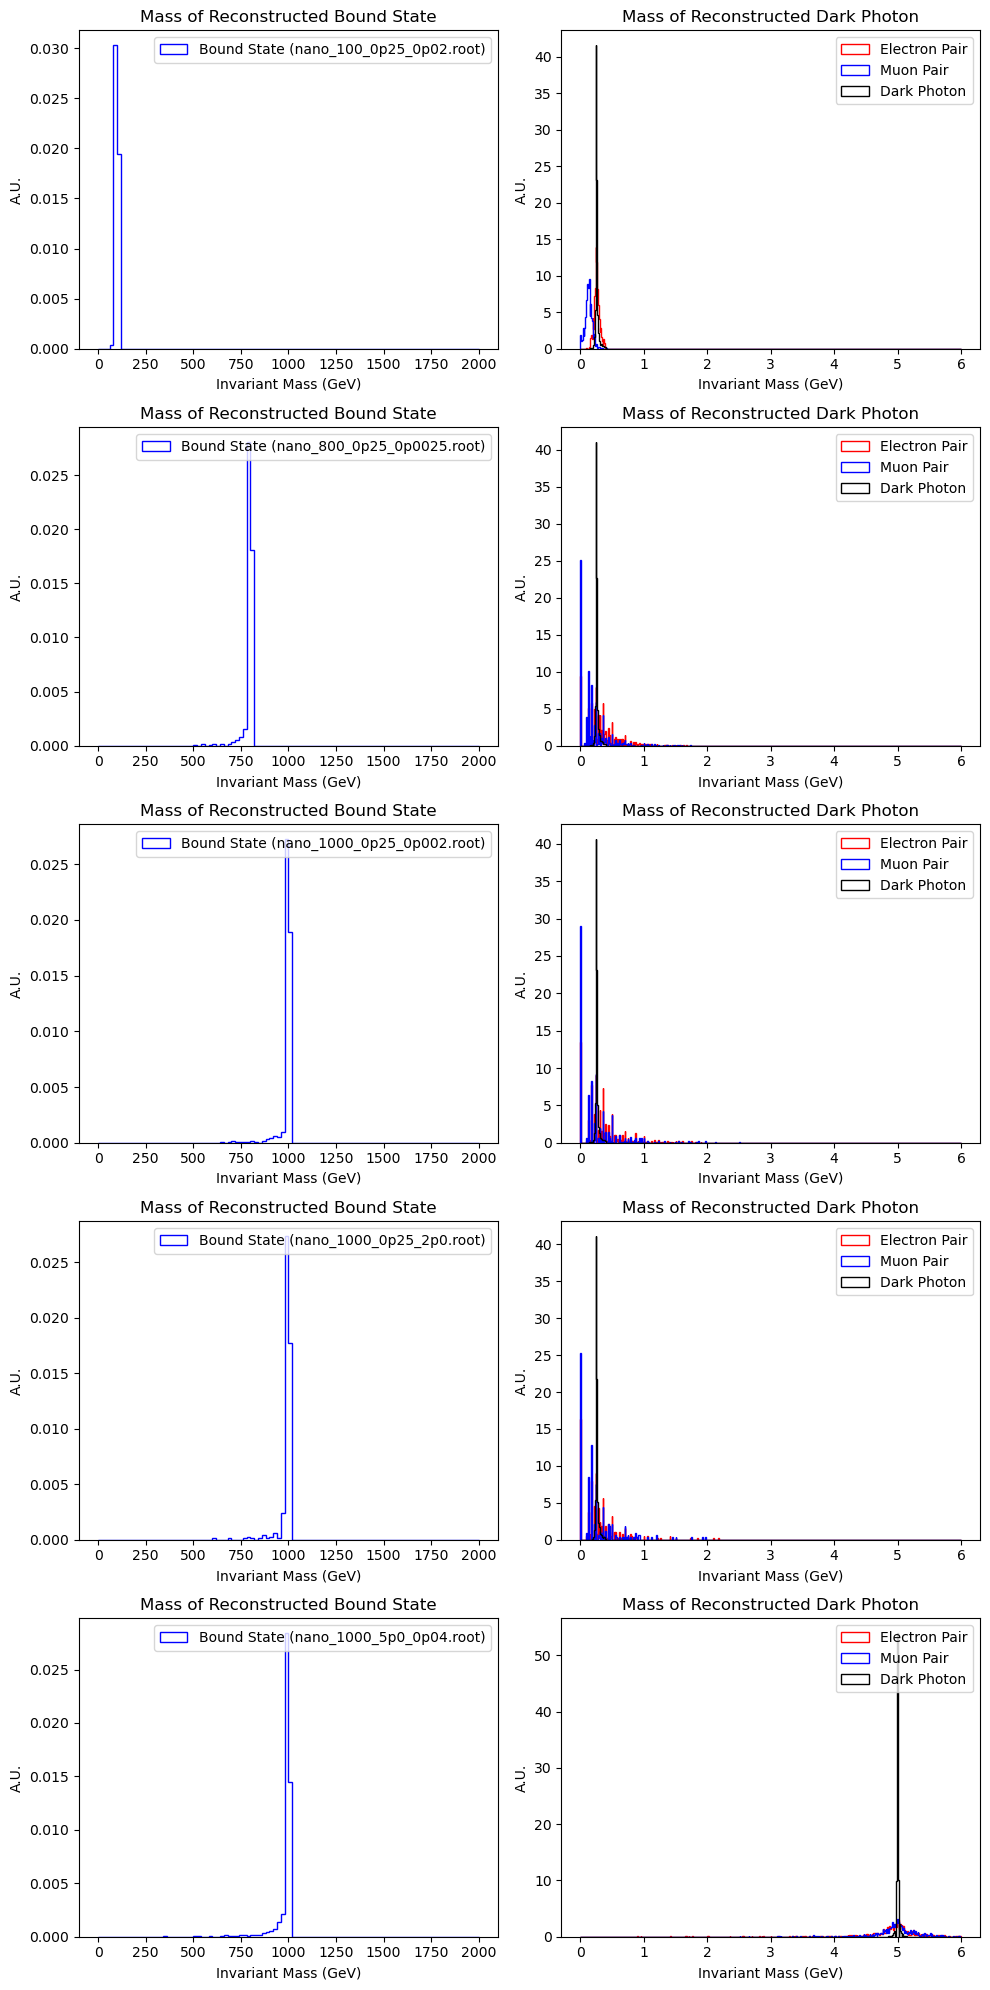

In [6]:
file = ["nano_100_0p25_0p02.root","nano_800_0p25_0p0025.root","nano_1000_0p25_0p002.root","nano_1000_0p25_2p0.root","nano_1000_5p0_0p04.root"]
target_file = [branches_dict[name] for name in file]
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    current_name = file[i]
    axes[i, 0].hist(target_file[i]["bound_state"].mass, bins=100, range=(0, 2000), color='blue', label=f"Bound State ({current_name})", histtype='step',density=True)
#The reconstructed mass of the electron pair and muon pair is greater than the sum of its parts, because the calculation
#doesn't simply add up the two pairs' invariant masses. It accounts for the angle of separation and momenta of the 
#pairs as they are detected in the calorimeter to calculate the original mass of the bound state.

#Plotting the mass of just the gen electron pair, reconstructed as one of the 'Dark Photons'
#Both dark photons are practically indistinguishable and notably, they have significantly less mass than the bound state.
    axes[i, 1].hist(target_file[i]["e_pair"].mass, bins=500, range=(0, 6), color='red', label = "Electron Pair", histtype='step',density=True)
    axes[i, 1].hist(target_file[i]["mu_pair"].mass, bins=500, range=(0, 6), color='blue', label = "Muon Pair", histtype='step',density=True)
    axes[i, 1].hist(target_file[i]["dark_photon"].mass, bins=500, range=(0, 6), color='black', label = "Dark Photon", histtype='step', density=True)

    axes[i, 1].set_xlabel('Invariant Mass (GeV)')
    axes[i, 1].set_ylabel('A.U.')

    axes[i, 0].set_xlabel('Invariant Mass (GeV)')
    axes[i, 0].set_ylabel('A.U.')

    axes[i, 0].set_title('Mass of Reconstructed Bound State')
    axes[i, 1].set_title('Mass of Reconstructed Dark Photon')
    
    axes[i, 0].legend(loc='upper right')
    axes[i, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

Figure 1. In these figures, the invariant mass of the bound state is significantly higher than the combined invariant mass of two dark photons. This is despite the fact that the mass becomes entirely photons. The reason for the disparity is that the photons have much higher energy which is observed in its higher momentum and accounted for in the angle between offshoot electron and muon pairs. 

The mass of the bound state is exactly as we predict it in every plot, but the only dark photon which has correct mass is the 5 GeV. The file with a 100 GeV bound state and 0.25 GeV dark photon has almost the correct graph, but the muon pair has less GeV for some reason. The other three plots have unpredicted, isolated spikes which skew right. I'm not exactly sure the reason that four of the five plots behave weirdly.

# Momenta of Different Bound State Masses

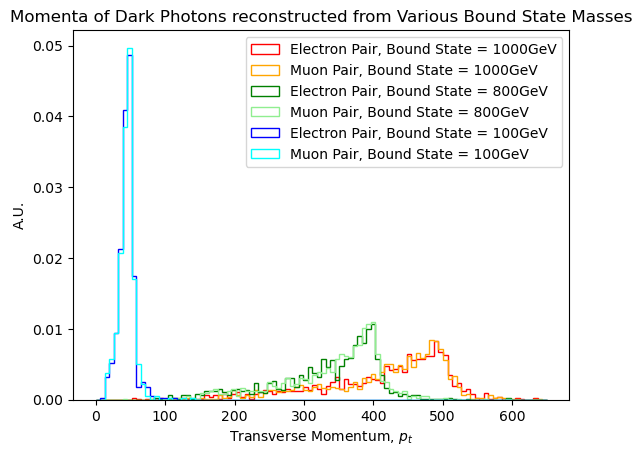

In [8]:
nano_1000_5p0_0p04 = branches_dict["nano_1000_5p0_0p04.root"]
nano_800_0p25_0p0025 = branches_dict["nano_800_0p25_0p0025.root"]
nano_100_0p25_0p02 = branches_dict["nano_100_0p25_0p02.root"]


plt.hist(nano_1000_5p0_0p04["e_pair"].pt, bins=100, range=(0, 650), color='red', label = "Electron Pair, Bound State = 1000GeV", histtype='step',density=True)
plt.hist(nano_1000_5p0_0p04["mu_pair"].pt, bins=100, range=(0, 650), color='orange', label = "Muon Pair, Bound State = 1000GeV", histtype='step',density=True)

plt.hist(nano_800_0p25_0p0025["e_pair"].pt, bins=100, range=(0, 650), color='green', label = "Electron Pair, Bound State = 800GeV", histtype='step',density=True)
plt.hist(nano_800_0p25_0p0025["mu_pair"].pt, bins=100, range=(0, 650), color='lightgreen', label = "Muon Pair, Bound State = 800GeV", histtype='step',density=True)

plt.hist(nano_100_0p25_0p02["e_pair"].pt, bins=100, range=(0, 650), color='blue', label = "Electron Pair, Bound State = 100GeV", histtype='step',density=True)
plt.hist(nano_100_0p25_0p02["mu_pair"].pt, bins=100, range=(0, 650), color='cyan', label = "Muon Pair, Bound State = 100GeV", histtype='step',density=True)

#in deliverable:talk about mass of electrons vs mass of photons vs mass of bound state. m_e and m_mu are both small because its invariant mass, but mass uses reconstructed formula that takes into account angle between offshoot particles and the momenta of the particles.

plt.xlabel(r'Transverse Momentum, $p_t$')
plt.ylabel('A.U.')
plt.title('Momenta of Dark Photons reconstructed from Various Bound State Masses')
plt.legend(loc = 'upper right')
plt.show()

Figure 2. I attempted to recreate the first plot of fig 2. of the CMS paper, "Search for Self-Interacting Dark Matter in events with two Lepton Jets." This plot compares the reconstructed transverse momenta of dark photons (measured via the lepton pairs they decay into) created by dark matter bound states of various masses. The reconstructed photons' $p_t$ spike at half of the bound state mass. This is expected because the bound state is very massive and has an extremely low velocity and the electron and muon pairs have a very low mass. The transverse momentum and energy is conserved when the bound state splits into the two dark photons, which is seen via the lepton pairs.

# Momenta of Leading and Subleading Particles

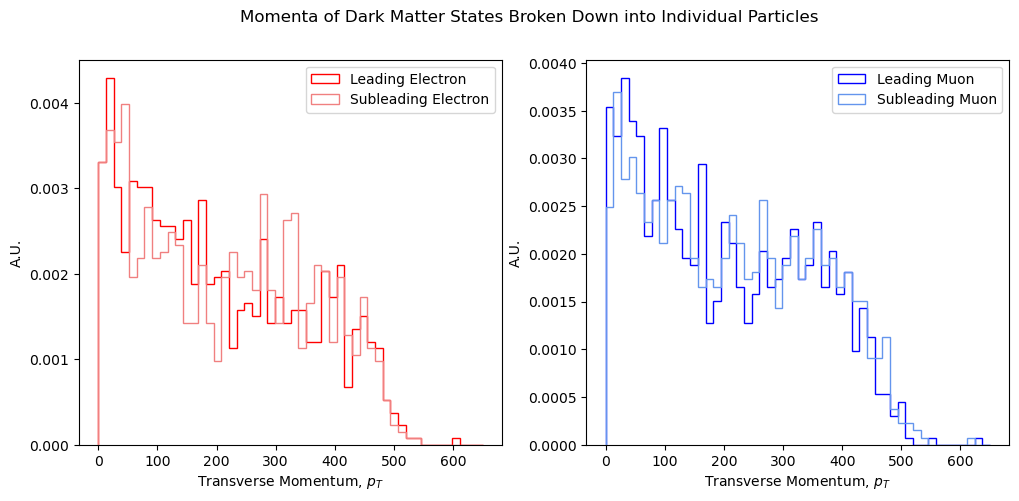

In [9]:
target_file = branches_dict["nano_1000_5p0_0p04.root"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plotting individual Electrons
ax1.hist(target_file["leading_e"].pt, bins=50, range=(0, 650), color='red', label="Leading Electron", histtype='step', density=True)
ax1.hist(target_file["subleading_e"].pt, bins=50, range=(0, 650), color='lightcoral', label="Subleading Electron", histtype='step', density=True)

# Plotting individual Muons
ax2.hist(target_file["leading_mu"].pt, bins=50, range=(0, 650), color='blue', label="Leading Muon", histtype='step', density=True)
ax2.hist(target_file["subleading_mu"].pt, bins=50, range=(0, 650), color='cornflowerblue', label="Subleading Muon", histtype='step', density=True)

ax2.set_xlabel(r'Transverse Momentum, $p_T$')
ax2.set_ylabel('A.U.')

ax1.set_xlabel(r'Transverse Momentum, $p_T$')
ax1.set_ylabel('A.U.')


plt.suptitle('Momenta of Dark Matter States Broken Down into Individual Particles')
ax2.legend(loc = 'upper right')
ax1.legend(loc = 'upper right')
plt.show()

Figure 3. When dark photons decay into lepton pairs, they already have a high velocity and momentum. In the rest frame of the dark photon, the two leptons have equal but opposite momenta. But in the rest frame of the laboratory, the electrons and muons are given a "boost," which contributes to a higher transverse momentum for one particle while fights against the other leading to a lower transverse momentum. It's important to distinguish the two leptons in reconstruction, because we need to gauge whether we would actually observe both particles experimentally and what $p_T$ they would have.